In [ ]:
# 1. Install playwright and the stealth plugin
# !pip install playwright playwright-stealth
!pip install playwright

# 2. Install the browser binaries
!playwright install chromium

# 3. Install system dependencies (Crucial for Colab!)
!playwright install-deps chromium

from playwright.sync_api import sync_playwright
from bs4 import BeautifulSoup
import multiprocessing
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def manual_stealth_scraper(url, queue):
    try:
        with sync_playwright() as p:
            # We use a real browser launch with 'args' to disable the bot flags manually
            browser = p.chromium.launch(headless=True, args=[
                '--disable-blink-features=AutomationControlled',
            ])

            context = browser.new_context(
                user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",
                viewport={'width': 1920, 'height': 1080}
            )

            # Manually inject a script to hide the 'webdriver' property
            page = context.new_page()
            page.add_init_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")

            print(f"Accessing: {url}")
            page.goto(url, wait_until="domcontentloaded")

            # Wait for the Cloudflare "Just a moment" check
            time.sleep(10)

            content = page.content()
            browser.close()
            queue.put(content)
    except Exception as e:
        queue.put(f"PROCESS_ERROR: {str(e)}")

def run_manual_scraper(url):
    queue = multiprocessing.Queue()
    p = multiprocessing.Process(target=manual_stealth_scraper, args=(url, queue))
    p.start()
    result = queue.get()
    p.join()

    if result.startswith("PROCESS_ERROR"):
        return result
    return BeautifulSoup(result, 'html.parser')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 16.9 MB/s eta 0:00:00
(node:2203) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
167.3 MiB [] 0% 0.0s167.3 MiB [] 0% 46.5s167.3 MiB [] 0% 20.1s167.3 MiB [] 0% 17.9s167.3 MiB [] 0% 19.6s167.3 MiB [] 0% 17.1s167.3 MiB [] 0% 10.7s167.3 MiB [] 1% 7.3s167.3 MiB [] 2% 6.0s167.3 MiB [] 3% 4.8s167.3 MiB [] 3% 4.4s167.3 MiB [] 4% 4.4s167.3 MiB [] 5% 3.8s167.3 MiB [] 6% 3.4s167.3 MiB [] 6% 3.2s167.3 MiB [] 7% 3.1s167.3 MiB [] 8% 3.1s167.3 MiB [] 9% 3.0s167.3 MiB [] 10% 2.9s167.3 MiB [] 11% 2.7s167.3 MiB [] 11% 2.6s167.3 MiB [] 12% 2.7s167.3 MiB [] 13% 2.6s167.3 MiB [] 14% 2.5s167.3 MiB [] 15% 2.5s167.3 MiB [] 15% 2.6s167.3 MiB [] 16% 2.6s167.3 MiB [] 17% 2.5s167.3 MiB [] 18% 2.4s167.3 MiB [] 19% 2.4s167

# Load in Data

In [ ]:
import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
db = pd.read_csv("database2.csv")
db = pd.concat([pd.read_csv("database25.csv"), db]).drop("Unnamed: 0", axis = 1)

## making mirrored dataset (most recent features)

In [ ]:
db_used = db.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()
db_used["net_eFG"] = db["eFG_team1"] - db["opp_eFG_team2"]
db_used["net_TOV_pct"] = db["TOV_pct_team1"] - db["opp_TOV_pct_team2"]
db_used

# # for augmented section
mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db["eFG_team2"] - db["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db["TOV_pct_team2"] - db["opp_TOV_pct_team1"]
mirrored

,seed_diff,SRS_diff,SOS_diff,off_rtg_diff,def_rtg_diff,pace_diff,eFG_diff,ORB_pct_diff,FT_FGA_diff,TOV_pct_diff,3PAr_diff,net_eFG,net_TOV_pct
0,15,-38.63,-16.74,-21.735268,8.235171,1.307545,-0.059940,-0.047013,-0.019514,6.508901,-0.044042,0.068681,4.155121
1,1,1.63,2.07,0.693676,-2.185125,-3.850556,0.000873,0.020319,0.006590,0.714957,-0.023413,-0.000592,-2.917997
2,7,-10.58,-13.31,4.330788,-8.304213,-1.853570,0.066297,-0.081319,-0.060892,-0.478718,0.099201,0.098112,-1.628712
3,9,-19.72,-17.47,0.625503,-0.038769,2.362259,0.028110,-0.026407,-0.091623,0.133539,0.114688,0.071264,0.079987
4,5,-4.62,-8.91,-1.973153,-9.253396,-1.120285,-0.046395,0.051211,0.031260,-0.720682,-0.007199,0.019433,-0.995170
...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,-1,0.01,-4.08,4.119806,-5.946580,-2.714394,0.037310,-0.006087,-0.035741,0.045423,0.007524,0.065433,-0.683358
815,-2,1.41,2.45,-4.124360,-1.233069,-0.698599,-0.062671,0.060672,-0.069699,-2.199080,-0.075613,-0.002986,-2.031788
816,1,2.35,-1.53,4.710034,-3.375732,0.982822,0.042252,-0.041891,0.006869,-0.734366,0.026172,0.070374,-1.463147
817,-3,2.97,1.24,1.862873,-4.182160,-0.032207,0.004145,0.004428,0.012141,-0.546531,-0.037982,0.008802,-4.532685


# Preparing X and y

In [ ]:
not_included: set[str] = {"season","round","team1","team2","team1_seed","team2_seed","win"}
# X = db.loc[:,list(c for c in db.columns if c not in not_included)]
y = np.array(db["win"]).reshape(-1,1)

# augmenting
# mirrored = db.loc[:,["season","round","team2","team1","team2_seed","team1_seed", "win"] + list(c for c in db.columns if "_team2" in c) + list(c for c in db.columns if "_team1" in c)].copy()
# X = np.vstack([db.loc[:,list(c for c in db.columns if c not in not_included)], mirrored.loc[:,list(c for c in mirrored.columns if c not in not_included)]])

# pared and augmented
# db_used = db.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA"}))].copy()
# mirrored = db_used.loc[:,["team2_seed","team1_seed"] + list(c for c in db_used.columns if "_team2" in c) + list(c for c in db_used.columns if "_team1" in c)].copy()
# X = np.vstack([db_used, mirrored])

# diffs
db_used = db.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_eFG"] = db["eFG_team1"] - db["opp_eFG_team2"]
db_used["net_TOV_pct"] = db["TOV_pct_team1"] - db["opp_TOV_pct_team2"]

# # for augmented section
mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db["eFG_team2"] - db["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db["TOV_pct_team2"] - db["opp_TOV_pct_team1"]
mirrored

X = np.vstack([np.array(db_used), np.array(mirrored)])

# diffs with more columns
# db_used = db.loc[:,list(c for c in db.columns if "opp" not in c and "_G" not in c and "net" not in c)].copy()
# db_used = db_used.loc[:,list(c for c in db_used.columns if c not in {"season","round","team1","team2"})].copy()
# comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
# db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
# for comp in comps:
#     db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
# db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()
# X = np.array(db_used)

# augmenting diffs
# X = np.vstack([X, -X])
y = np.vstack([y, 1 - y])

# y = np.vstack([y.reshape(-1,1), y.reshape(-1,1)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.as_tensor(X_train, dtype = torch.float32)
X_test = torch.as_tensor(X_test, dtype = torch.float32)
# y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
# y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [ ]:
import pickle

# Save the scaler to a file in binary write mode ('wb')
with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

## batch loader

In [ ]:
from torch.utils.data import DataLoader

bs: int = 35

class HousingDataset(DataLoader):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

training_data = HousingDataset(X_train, y_train)
valid_data = HousingDataset(X_test, y_test)
train_dataloader = DataLoader(training_data, batch_size=bs, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=bs, shuffle=True)

In [ ]:
class Model(torch.nn.Module):

    def __init__(self, input_size: int, output_size: int = 2, hidden_layers: int = 3):
        super(Model, self).__init__()
        self.linear = torch.nn.Linear(input_size, 32, bias = 0)
        self.n_layers = hidden_layers
        self.relu = torch.nn.ReLU()
        if self.n_layers > 0:
            self.hidden_layers = [torch.nn.Linear(32, 32, bias = 0) for _ in range(self.n_layers)]
            self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(32, 32, bias=0) for _ in range(self.n_layers)])
        self.lastlinear = torch.nn.Linear(32, output_size)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):

        x = self.linear(x)
        z = self.relu(x)
        if self.n_layers > 0:
            for i in range(self.n_layers):
                z = self.hidden_layers[i](z)
                z = self.relu(z)
        z = self.lastlinear(z)
        y = self.sigmoid(z)

        return y

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(input_size, hidden_dim))

        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        for layer in self.layers:
            x = self.relu(layer(x))
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

# Model Training

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

In [ ]:
def error_measures(y_pred, y_true, thresh = .5, roc: bool = False):

    n: int = y_pred.shape[0]
    # acc: float = sum(torch.round(y_pred) == y_true).item()/n

    y_pred = y_pred > thresh

    measures: dict[str, int] = {
        "TP" : 0, "TN" : 0,
        "FP" : 0,  "FN" : 0
    }

    for i in range(n):
        if y_pred[i] + y_true[i] == 2:
            measures["TP"] += 1
        elif y_pred[i] + y_true[i] == 0:
            measures["TN"] += 1
        elif y_pred[i] == 1:
            measures["FP"] += 1
        else:
            measures["FN"] += 1

    if roc:
        return measures["TP"]/(measures["TP"] + measures["FN"]), measures["FP"]/(measures["FP"] + measures["TN"])
    else:
        print(f"""
        Accuracy: {(measures["TP"] + measures["TN"])/n}
        TPR: {measures["TP"]/(measures["TP"] + measures["FN"])}
        FPR: {measures["FP"]/(measures["FP"] + measures["TN"])}
        Precision: {measures["TP"]/(measures["FP"] + measures["TP"])}
        """)

In [ ]:
hyperparameters = pd.DataFrame(columns = ["train_loss", "test_loss", "hidden_layers", "lr", "lambda", "epochs", "augmented", "features","dropout","dropout_val", "hidden_size","batchnorm", "early_stopping", "best_test_loss"])

Epoch 25:
Train:

        Accuracy: 0.7590361445783133
        TPR: 0.76410998552822
        FPR: 0.24583333333333332
        Precision: 0.7489361702127659
        
Test:

        Accuracy: 0.7393767705382436
        TPR: 0.7277486910994765
        FPR: 0.24691358024691357
        Precision: 0.776536312849162
        
Epoch 50:
Train:

        Accuracy: 0.7668320340184267
        TPR: 0.7713458755426917
        FPR: 0.2375
        Precision: 0.7571022727272727
        
Test:

        Accuracy: 0.7308781869688386
        TPR: 0.7329842931937173
        FPR: 0.2716049382716049
        Precision: 0.7608695652173914
        
Epoch 75:
Train:

        Accuracy: 0.7682494684620836
        TPR: 0.7698986975397974
        FPR: 0.23333333333333334
        Precision: 0.76
        
Test:

        Accuracy: 0.7563739376770539
        TPR: 0.7643979057591623
        FPR: 0.25308641975308643
        Precision: 0.7807486631016043
        
Early stopping!
Final Train Loss: 0.5175280905351406
Final Tes

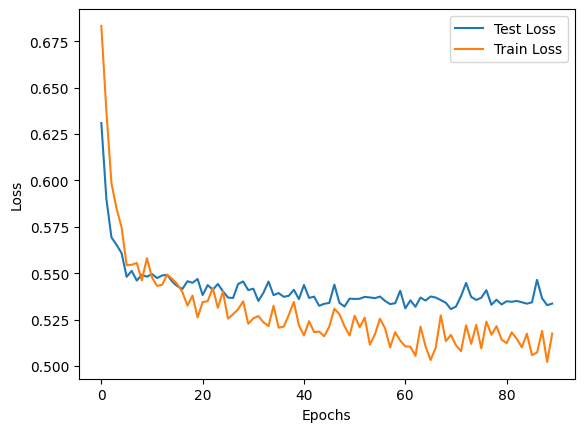

In [ ]:
torch.manual_seed(0)

dropout: int = 1
dropout_val: float = .3
augmented: int = 1
hidden: int = 2
hidden_size: int = 32
batch_norm: int = 1
early_stopping: int = 1
model = Model(X_train.shape[1], n_layers = hidden, hidden_dim=hidden_size, dropout = dropout_val)

patience: int = 20
wait: int = 0
best_loss: float = float("inf")
best_model_state = None

loss_fn = torch.nn.BCELoss()

lr = 0.001
lamb = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = lamb)

epochs: int = 250

train_loss: list[float] = list()
test_loss: list[float] = list()

for epoch in range(epochs):
    train_loss.append(0)
    model.train()
    for batchX, batchy in train_dataloader:
        pred = model(batchX)
        loss = loss_fn(pred, batchy)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss[epoch] += loss.item()

    train_loss[epoch] /= len(train_dataloader)
    # print(f"Epoch {epoch}: {train_loss / len(train_dataloader)}")
    # test_loss.append(loss_fn(model(X_test), y_test).item())

    # if (epoch + 1) % 25 == 0:
    #     print(f"Epoch {epoch + 1}:")
    #     print(f"Train:")
    #     error_measures(model(X_train), y_train)
    #     print(f"Test:")
    #     error_measures(model(X_test), y_test)

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test), y_test)
        test_loss.append(val_loss.item())
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch + 1}:")
            print(f"Train:")
            error_measures(model(X_train), y_train)
            print(f"Test:")
            error_measures(model(X_test), y_test)
        # print(f"Epoch {epoch}: Val Loss = {val_loss.item():.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            wait = 0
            best_model_state = model.state_dict()  # Save the best model
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping!")
                break

print(f"Final Train Loss: {train_loss[-1]}")
print(f"Final Test Loss: {test_loss[-1]}")

hyperparameters.loc[len(hyperparameters.index)] = [train_loss[-1],
  test_loss[-1], hidden, lr, lamb, epoch + 1, augmented, X.shape[1],
  dropout, dropout_val, hidden_size, batch_norm, early_stopping, best_loss.item()]

plt.plot(range(epoch + 1), test_loss, label='Test Loss')
plt.plot(range(epoch + 1), train_loss, label='Train Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
hyperparameters.iloc[-2:]

,train_loss,test_loss,hidden_layers,lr,lambda,epochs,augmented,features,dropout,dropout_val,hidden_size,batchnorm,early_stopping,best_test_loss
0,0.517528,0.533622,2.0,0.001,0.01,90.0,1.0,13.0,1.0,0.3,32.0,1.0,1.0,0.530609


In [ ]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

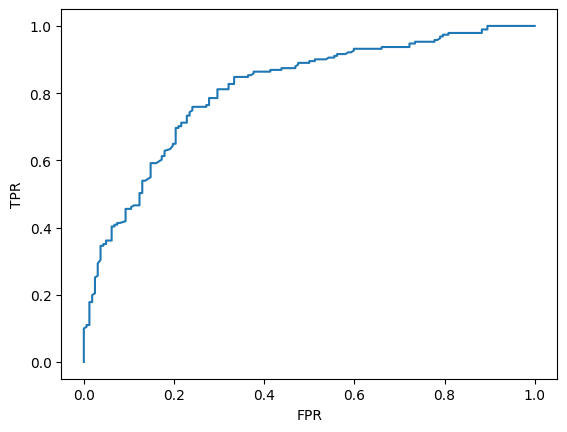

In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(model(X_test), y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
best

(0.473, 0.5184215629241807)

In [ ]:
# best combo so far with lowest loss
# error_measures(model(X_test), y_test, .676, roc = 0)
error_measures(model(X_test), y_test, best[0], roc = 0)


        Accuracy: 0.7592067988668555
        TPR: 0.7591623036649214
        FPR: 0.24074074074074073
        Precision: 0.7880434782608695
        


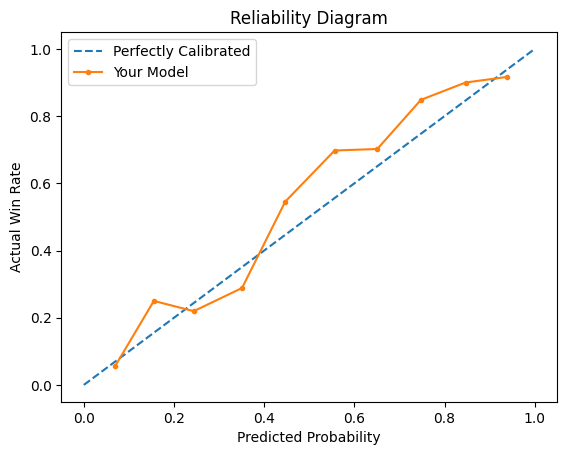

In [ ]:
from sklearn.calibration import calibration_curve

# 1. Get raw probabilities (don't use the threshold yet!)
model.eval()
with torch.no_grad():
    probs = model(X_test).cpu().numpy()

# 2. Calculate calibration
# n_bins=10 means we check buckets: 0-10%, 10-20%, etc.
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

# 3. Plot
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred, prob_true, marker='.', label='Your Model')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.legend()
plt.title('Reliability Diagram')
plt.show()

In [ ]:
(hyperparameters.iloc[-2:])

,train_loss,test_loss,hidden_layers,lr,lambda,epochs,augmented,features,dropout,dropout_val,hidden_size,batchnorm,early_stopping,best_test_loss
42,0.489433,0.557330,1.0,0.00025,0.01,98.0,1.0,34.0,1.0,0.2,32.0,1.0,1.0,0.544097
43,0.483318,0.546689,2.0,0.00025,0.01,79.0,1.0,34.0,1.0,0.2,32.0,1.0,1.0,0.543021


In [ ]:
torch.save(best_model_state, "mod13v2.pth")

# Making Trees

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

## learning XGB

In [ ]:
model = XGBClassifier(objective='binary:logistic', n_estimators=600, learning_rate=0.1)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
error_measures(model.predict_proba(X_test)[:,1], y_test.reshape(-1), .273, roc = 0)


        Accuracy: 0.7422096317280453
        TPR: 0.7591623036649214
        FPR: 0.2777777777777778
        Precision: 0.7631578947368421
        


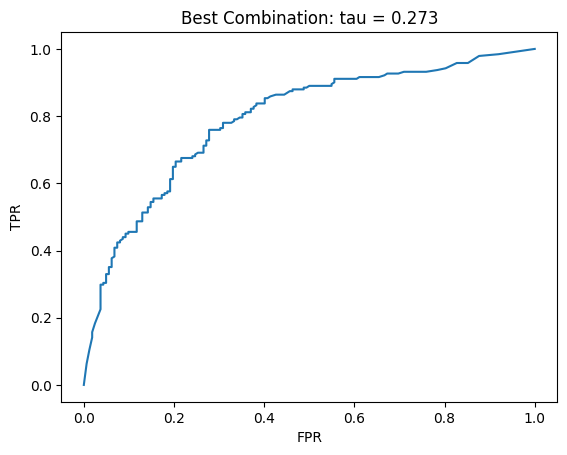

In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(model.predict_proba(X_test)[:,1], y_test.reshape(-1), t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"Best Combination: tau = {best[0]}")
plt.show()

ROC AUC Score: 0.7898


<Figure size 640x480 with 0 Axes>

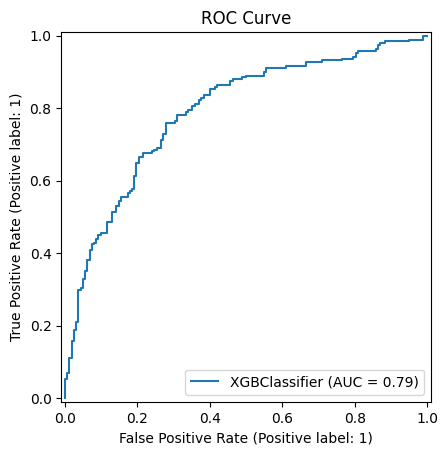

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
print(f"ROC AUC Score: {roc_auc:.4f}")


plt.figure()
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

### looping XGB

In [ ]:
loss_fn = torch.nn.BCELoss()

In [ ]:
XG_testing = pd.DataFrame(columns = ["est", "lr", "l2", "l1", "train loss","test loss", "test acc"]) #, "best tau", "acc", "tpr", "fpr","prec", "ROC"])

In [ ]:
# for e in range(100,1001,50):
for e in range(100,750,50):
    for f in [.01, .025, .05, .1]:
    # for f in [.01,.025]:
        for l2 in [.2, .5, 1, 2, 5]:
            for l1 in [0, .2, .5, 1, 2, 5]:
                # lr = f
                model = XGBClassifier(objective='binary:logistic', n_estimators=e, learning_rate=lr, reg_lambda = l2, reg_alpha = l1)
                model.fit(X_train, y_train)
                XG_testing.loc[len(XG_testing.index)] = [
                    e, lr, l2, l1,
                    loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1))).item(),
                    loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1))).item(),
                    (torch.sum(model.predict(X_test) == y_test.reshape(-1))/353).item()
                ]

KeyboardInterrupt: 

In [ ]:
model = XGBClassifier(objective='binary:logistic', n_estimators=200, learning_rate=.01)
model.fit(X_train, y_train)
[loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1))).item(),
loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1))).item(),
(torch.sum(model.predict(X_test) == y_test.reshape(-1))/353).item()]

[0.36125269532203674, 0.5551735162734985, 0.7082152962684631]

In [ ]:
model.feature_importances_

array([0.05763148, 0.43243906, 0.05334806, 0.05302805, 0.04577725,
       0.04850154, 0.057946  , 0.04305478, 0.0528322 , 0.04056531,
       0.03911217, 0.03750371, 0.03826033], dtype=float32)

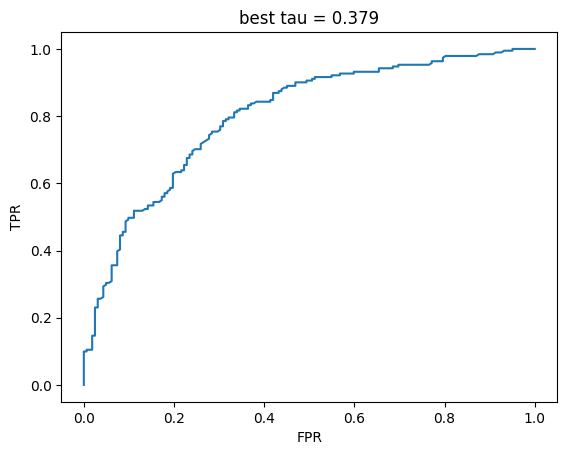

In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    TPR, FPR = error_measures(model.predict_proba(X_test)[:,1], y_test, t/1000, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (t/1000, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"best tau = {best[0]}")
plt.show()

In [ ]:
error_measures(model.predict_proba(X_test)[:,1], y_test, .379, roc = 0)


        Accuracy: 0.7450424929178471
        TPR: 0.8115183246073299
        FPR: 0.3333333333333333
        Precision: 0.7416267942583732
        


In [ ]:
XG_testing.sort_values("test loss") #, ascending=1).head(5)

,est,lr,l2,l1,train loss,test loss,test acc
2075,100.0,0.1,0.200,5.0,0.287876,0.565817,0.736544
1784,150.0,0.1,0.200,5.0,0.287876,0.565817,0.736544
1809,150.0,0.1,0.200,5.0,0.287876,0.565817,0.736544
2195,150.0,0.1,0.200,5.0,0.287876,0.565817,0.736544
1734,100.0,0.1,0.200,5.0,0.287876,0.565817,0.736544
...,...,...,...,...,...,...,...
1305,750.0,0.1,0.001,0.0,0.007667,0.966395,0.711048
1355,750.0,0.1,0.001,0.0,0.007667,0.966395,0.711048
1430,800.0,0.1,0.001,0.0,0.007148,0.975877,0.705382
1455,800.0,0.1,0.001,0.0,0.007148,0.975877,0.705382


In [ ]:
XG_testing.sort_values("test loss", ascending=1).head(5)

,est,lr,train loss,test loss,test acc
8,200.0,0.010,0.361253,0.555174,0.708215
12,250.0,0.010,0.334354,0.555693,0.708215
16,300.0,0.010,0.315169,0.557699,0.713881
4,150.0,0.010,0.397087,0.557775,0.716714
1,100.0,0.025,0.333652,0.559561,0.696884


## random forest

In [ ]:
torch.as_tensor(model.predict_proba(X_train)[:,1])
torch.as_tensor(y_train, dtype = torch.float64).reshape(-1).shape

torch.Size([1411])

In [ ]:
# loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1), dtype = torch.float64)).item()
# loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1), dtype = torch.float64)).item()

0.8430698925083517

In [ ]:
# [100, 2, 12, 0.5425639024180237]
# [50, 2, 13, 0.5424151825642104]
best = [-1, -1, -1, -1, .56]
for est in range(50, 750, 50):
    for md in range(1, 9):
        for mf in range(1, 14):
            for msl in range(1,16):
                model = RandomForestClassifier(random_state=0, n_estimators=est, max_depth = md, max_features = mf, min_samples_leaf=msl)
                model.fit(X_train, y_train.reshape(-1))
                train_loss = loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1), dtype = torch.float64)).item()
                test_loss = loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1), dtype = torch.float64)).item()
                best_tau: tuple[float, float] = (0, -1)
                if test_loss < best[-1] or test_loss < .55:
                    best = [est, md, mf, msl, test_loss]
                    for t in range(0,501):
                        tau = t/500
                        TPR, FPR = error_measures(model.predict_proba(X_test)[:,1], y_test, tau, roc = 1)
                        if TPR - FPR > best_tau[1]:
                            best_tau = (tau, TPR - FPR)
                    print(f"Best tau: {best_tau[0]}")
                    error_measures(model.predict_proba(X_test)[:,1], y_test, best_tau[0], roc = 0)
                    print(best)

Best tau: 0.542

        Accuracy: 0.7535410764872521
        TPR: 0.6596858638743456
        FPR: 0.13580246913580246
        Precision: 0.8513513513513513
        
[50, 2, 4, 1, 0.5570851840823327]
Best tau: 0.542

        Accuracy: 0.7535410764872521
        TPR: 0.6596858638743456
        FPR: 0.13580246913580246
        Precision: 0.8513513513513513
        
[50, 2, 4, 2, 0.5569946328563437]
Best tau: 0.542

        Accuracy: 0.7535410764872521
        TPR: 0.6596858638743456
        FPR: 0.13580246913580246
        Precision: 0.8513513513513513
        
[50, 2, 4, 4, 0.5568581837581913]
Best tau: 0.542

        Accuracy: 0.7507082152974505
        TPR: 0.6544502617801047
        FPR: 0.13580246913580246
        Precision: 0.8503401360544217
        
[50, 2, 4, 5, 0.5567436389298706]
Best tau: 0.56

        Accuracy: 0.7308781869688386
        TPR: 0.6230366492146597
        FPR: 0.1419753086419753
        Precision: 0.8380281690140845
        
[50, 2, 5, 1, 0.5545781718117457]
Be

KeyboardInterrupt: 

In [ ]:
est, md, mf, msl = 50, 2, 13, 1
model = RandomForestClassifier(random_state=0, n_estimators=est, max_depth = md, max_features = mf, min_samples_leaf=msl)
model.fit(X_train, y_train.reshape(-1))
train_loss = loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1), dtype = torch.float64)).item()
test_loss = loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1), dtype = torch.float64)).item()
print(train_loss, test_loss)

0.5167604372998349 0.5424151825642104


In [ ]:
model.feature_importances_

array([1.62561371e-01, 6.11825627e-01, 1.24068134e-01, 4.09969804e-02,
       0.00000000e+00, 8.75514880e-04, 4.81235334e-03, 3.92197097e-02,
       0.00000000e+00, 1.16294847e-02, 6.18357244e-04, 4.75531098e-04,
       2.91693672e-03])

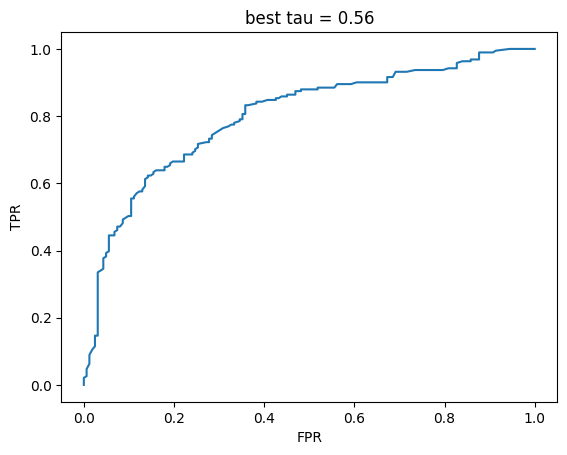


        Accuracy: 0.7308781869688386
        TPR: 0.6230366492146597
        FPR: 0.1419753086419753
        Precision: 0.8380281690140845
        


In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,501):
    tau = t/500
    TPR, FPR = error_measures(model.predict_proba(X_test)[:,1], y_test, tau, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"best tau = {best[0]}")
plt.show()

error_measures(model.predict_proba(X_test)[:,1], y_test, best[0], roc = 0)

## ada

In [ ]:
best = [-1, -1, -1, 1]
for est in range(50, 800, 50):
    for l in range(5, 100, 5):
        for md in range(1,16):
            lr = l/100
            model = AdaBoostClassifier(random_state=0,
                                      estimator = DecisionTreeClassifier(max_depth=md),
                                      n_estimators=est, learning_rate=lr)
            model.fit(X_train, y_train.reshape(-1))
            train_loss = loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1), dtype = torch.float64)).item()
            test_loss = loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1), dtype = torch.float64)).item()
            if test_loss < best[-1]:
                best = [est, lr, md, test_loss]
                print(best)

[50, 0.05, 1, 0.5385661975552808]


KeyboardInterrupt: 

In [ ]:
est, lr = 50, .05
model = AdaBoostClassifier(random_state=0, estimator=DecisionTreeClassifier(max_depth=1), n_estimators=est, learning_rate=lr)
model.fit(X_train, y_train.reshape(-1))
train_loss = loss_fn(torch.as_tensor(model.predict_proba(X_train)[:,1]), torch.as_tensor(y_train.reshape(-1), dtype = torch.float64)).item()
test_loss = loss_fn(torch.as_tensor(model.predict_proba(X_test)[:,1]), torch.as_tensor(y_test.reshape(-1), dtype = torch.float64)).item()
print(train_loss, test_loss)

0.5180265869117955 0.5385661975552808


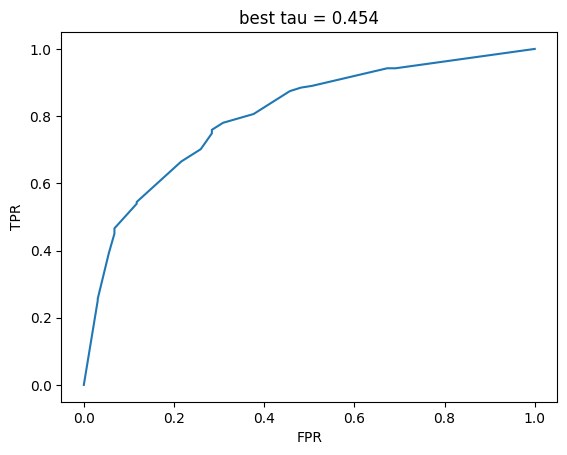


        Accuracy: 0.7393767705382436
        TPR: 0.7591623036649214
        FPR: 0.2839506172839506
        Precision: 0.7591623036649214
        


In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,501):
    tau = t/500
    TPR, FPR = error_measures(model.predict_proba(X_test)[:,1], y_test, tau, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"best tau = {best[0]}")
plt.show()

error_measures(model.predict_proba(X_test)[:,1], y_test, best[0], roc = 0)

In [ ]:
model.feature_importances_

array([0.        , 0.95858638, 0.04141362, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ])

# Data Process with a Valid Set

In [ ]:
import torch
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
db = pd.read_csv("database2.csv")
db = pd.concat([pd.read_csv("database25.csv"), db]).drop("Unnamed: 0", axis = 1)

In [ ]:
# not_included: set[str] = {"season","round","team1","team2","team1_seed","team2_seed","win"}
y = np.array(db["win"]).reshape(-1,1)

# diffs
db_used = db.loc[:,list(c for c in db.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_eFG"] = db["eFG_team1"] - db["opp_eFG_team2"]
db_used["net_TOV_pct"] = db["TOV_pct_team1"] - db["opp_TOV_pct_team2"]

# # for augmented section
mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db["eFG_team2"] - db["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db["TOV_pct_team2"] - db["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X13 = X.copy()
# X = X[:,:11]

y = np.vstack([y, 1 - y])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state = 0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

X_train = torch.as_tensor(X_train, dtype = torch.float32)
X_test = torch.as_tensor(X_test, dtype = torch.float32)
# y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
# y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [ ]:
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size = .5, random_state = 0)

In [ ]:
X13_train, X13_test, y13_train, y13_test = train_test_split(X13, y, test_size = .3, random_state = 0)

scaler = StandardScaler()
X13_train = scaler.fit_transform(X13_train)
X13_test = scaler.fit_transform(X13_test)

X13_train = torch.as_tensor(X13_train, dtype = torch.float32)
X13_test = torch.as_tensor(X13_test, dtype = torch.float32)
# y_train = torch.tensor(y_train, dtype = torch.float32).reshape(-1, 1)
# y_test = torch.tensor(y_test, dtype = torch.float32).reshape(-1, 1)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)
X13_test, X13_valid, y_test, y_valid = train_test_split(X13_test, y_test, test_size = .5, random_state = 0)

/tmp/ipykernel_203/3819063603.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype = torch.float32)
/tmp/ipykernel_203/3819063603.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype = torch.float32)


In [ ]:
# X_train.shape, X_test.shape, X_valid.shape
from torch.utils.data import DataLoader

bs: int = 25

class HousingDataset(DataLoader):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

training_data = HousingDataset(X_train, y_train)
valid_data = HousingDataset(X_test, y_test)
train_dataloader = DataLoader(training_data, batch_size=bs, shuffle=True)
valid_dataloader = DataLoader(valid_data, batch_size=bs, shuffle=True)

In [ ]:
class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

def error_measures(y_pred, y_true, thresh = .5, roc: bool = False):

    n: int = y_pred.shape[0]
    # acc: float = sum(torch.round(y_pred) == y_true).item()/n

    y_pred = y_pred >= thresh

    measures: dict[str, int] = {
        "TP" : 0, "TN" : 0,
        "FP" : 0,  "FN" : 0
    }

    for i in range(n):
        if y_pred[i] + y_true[i] == 2:
            measures["TP"] += 1
        elif y_pred[i] + y_true[i] == 0:
            measures["TN"] += 1
        elif y_pred[i] == 1:
            measures["FP"] += 1
        else:
            measures["FN"] += 1

    if roc:
        return measures["TP"]/(measures["TP"] + measures["FN"]), measures["FP"]/(measures["FP"] + measures["TN"])
    else:
        print(f"""
        Accuracy: {(measures["TP"] + measures["TN"])/n}
        TPR: {measures["TP"]/(measures["TP"] + measures["FN"])}
        FPR: {measures["FP"]/(measures["FP"] + measures["TN"])}
        Precision: {measures["TP"]/(measures["FP"] + measures["TP"])}
        """)

In [ ]:
hyperparameters = pd.DataFrame(columns = ["train_loss", "test_loss", "hidden_layers", "lr", "lambda", "epochs", "augmented", "features","dropout","dropout_val", "hidden_size","batchnorm", "early_stopping", "best_test_loss"])

Epoch 25:
Train:

        Accuracy: 0.7593192868719612
        TPR: 0.770764119601329
        FPR: 0.25158227848101267
        Precision: 0.7447833065810594
        
Test:

        Accuracy: 0.7622641509433963
        TPR: 0.7163120567375887
        FPR: 0.18548387096774194
        Precision: 0.8145161290322581
        
Early stopping!
Final Train Loss: 0.5262404924631119
Final Test Loss: 0.5333691835403442


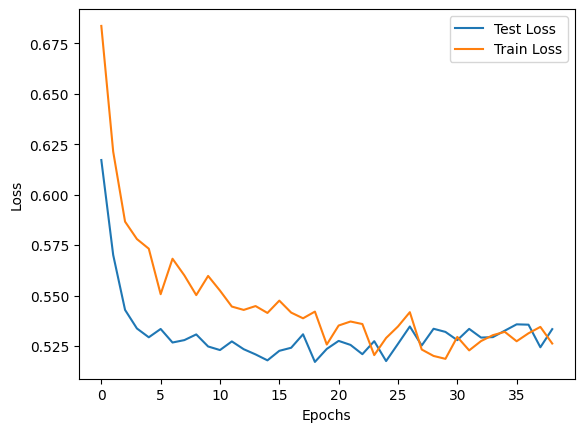

In [ ]:
torch.manual_seed(0)

dropout: int = 1
dropout_val: float = .3
augmented: int = 1
hidden: int = 2
hidden_size: int = 32
batch_norm: int = 1
early_stopping: int = 1
model = Model(X_train.shape[1], n_layers = hidden, hidden_dim=hidden_size, dropout = dropout_val)

patience: int = 20
wait: int = 0
best_loss: float = float("inf")
best_model_state = None

loss_fn = torch.nn.BCELoss()

lr = 0.001
lamb = 0.01

optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = lamb)

epochs: int = 250

train_loss: list[float] = list()
test_loss: list[float] = list()

for epoch in range(epochs):
    train_loss.append(0)
    model.train()
    for batchX, batchy in train_dataloader:
        pred = model(batchX)
        loss = loss_fn(pred, batchy)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss[epoch] += loss.item()

    train_loss[epoch] /= len(train_dataloader)
    # print(f"Epoch {epoch}: {train_loss / len(train_dataloader)}")
    # test_loss.append(loss_fn(model(X_test), y_test).item())

    # if (epoch + 1) % 25 == 0:
    #     print(f"Epoch {epoch + 1}:")
    #     print(f"Train:")
    #     error_measures(model(X_train), y_train)
    #     print(f"Test:")
    #     error_measures(model(X_test), y_test)

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_test), y_test)
        test_loss.append(val_loss.item())
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch + 1}:")
            print(f"Train:")
            error_measures(model(X_train), y_train)
            print(f"Test:")
            error_measures(model(X_test), y_test)
        # print(f"Epoch {epoch}: Val Loss = {val_loss.item():.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            wait = 0
            best_model_state = model.state_dict()  # Save the best model
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping!")
                break

print(f"Final Train Loss: {train_loss[-1]}")
print(f"Final Test Loss: {test_loss[-1]}")

hyperparameters.loc[len(hyperparameters.index)] = [train_loss[-1],
  test_loss[-1], hidden, lr, lamb, epoch + 1, augmented, X.shape[1],
  dropout, dropout_val, hidden_size, batch_norm, early_stopping, best_loss.item()]

plt.plot(range(epoch + 1), test_loss, label='Test Loss')
plt.plot(range(epoch + 1), train_loss, label='Train Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
hyperparameters

,train_loss,test_loss,hidden_layers,lr,lambda,epochs,augmented,features,dropout,dropout_val,hidden_size,batchnorm,early_stopping,best_test_loss
0,0.526240,0.533369,2.0,0.001,0.01,39.0,1.0,13.0,1.0,0.30,32.0,1.0,1.0,0.517124
1,0.535302,0.532291,2.0,0.001,0.02,54.0,1.0,11.0,1.0,0.35,32.0,1.0,1.0,0.519979
2,0.541712,0.527204,2.0,0.001,0.01,46.0,1.0,11.0,1.0,0.30,32.0,1.0,1.0,0.516981
3,0.526240,0.533369,2.0,0.001,0.01,39.0,1.0,13.0,1.0,0.30,32.0,1.0,1.0,0.517124


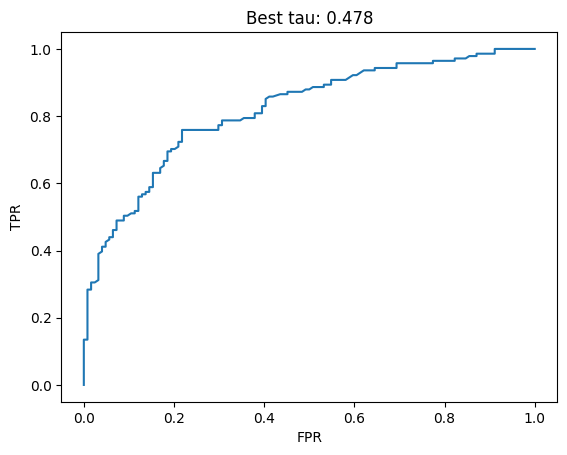

In [ ]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(model(X_test), y_test, tau, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.title(f"Best tau: {best[0]}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
error_measures(model(X_test), y_test, .478, roc = 0)


        Accuracy: 0.769811320754717
        TPR: 0.7588652482269503
        FPR: 0.21774193548387097
        Precision: 0.7985074626865671
        


In [ ]:
torch.save(best_model_state, "mod11.pth")

## Trees

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [ ]:
forest = RandomForestClassifier(random_state=0, n_estimators=500)
forest.fit(X_train, y_train.reshape(-1))

RandomForestClassifier(n_estimators=500, random_state=0)

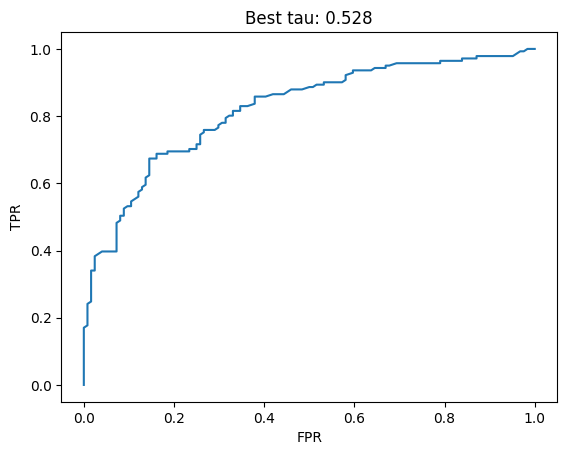

In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(forest.predict_proba(X_test)[:,-1], y_test, tau, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.title(f"Best tau: {best[0]}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [ ]:
error_measures(forest.predict_proba(X_test)[:,-1], y_test, best[0], roc = 0)


        Accuracy: 0.7584905660377359
        TPR: 0.6737588652482269
        FPR: 0.14516129032258066
        Precision: 0.8407079646017699
        


In [ ]:
ada = AdaBoostClassifier(random_state=0, learning_rate=.05,n_estimators=50)
ada.fit(X_train, y_train.reshape(-1))

AdaBoostClassifier(learning_rate=0.05, random_state=0)

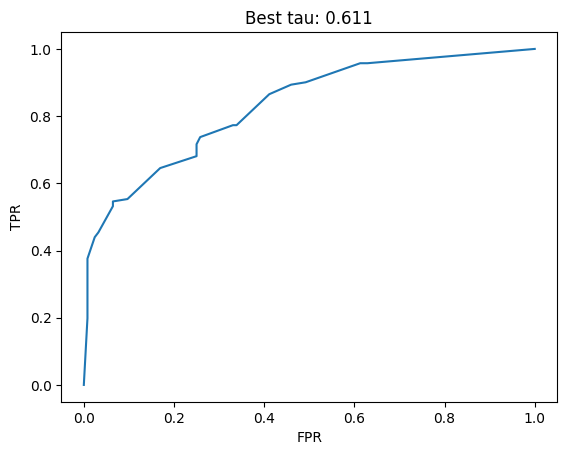


        Accuracy: 0.7283018867924528
        TPR: 0.5460992907801419
        FPR: 0.06451612903225806
        Precision: 0.9058823529411765
        


In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(ada.predict_proba(X_test)[:,-1], y_test, tau, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.title(f"Best tau: {best[0]}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()
error_measures(ada.predict_proba(X_test)[:,-1], y_test, best[0], roc = 0)

In [ ]:
XGB = XGBClassifier(objective='binary:logistic', n_estimators=350,
                    learning_rate=0.01, max_depth = 3)
XGB.fit(X_train, y_train)
loss_fn(torch.as_tensor(XGB.predict_proba(X_test)[:,-1], dtype = torch.float32).reshape(-1,1), y_test)

tensor(0.5128)

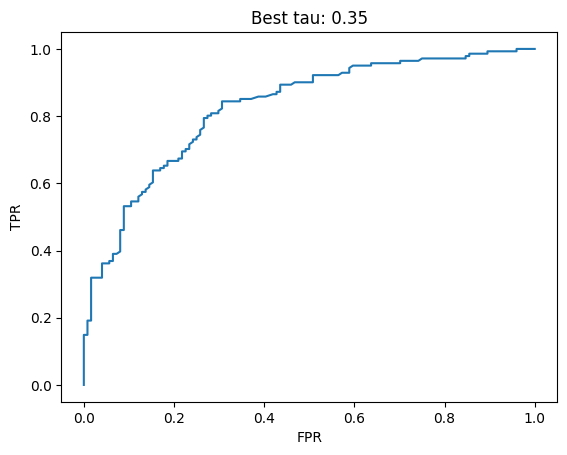


        Accuracy: 0.7735849056603774
        TPR: 0.8439716312056738
        FPR: 0.3064516129032258
        Precision: 0.7579617834394905
        


In [ ]:
TPRs: list[float] = list()
FPRs: list[float] = list()
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(XGB.predict_proba(X_test)[:,-1], y_test, tau, roc = 1)
    TPRs.append(TPR)
    FPRs.append(FPR)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
plt.plot(FPRs, TPRs)
plt.title(f"Best tau: {best[0]}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()
error_measures(XGB.predict_proba(X_test)[:,-1], y_test, best[0], roc = 0)

## valid set

In [ ]:
loss_fn(model(X_valid), y_valid).item()

0.544675886631012

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(model(X_valid), y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
error_measures(model(X_valid), y_valid,  best[0], roc = 0)


        Accuracy: 0.7283018867924528
        TPR: 0.697841726618705
        FPR: 0.23809523809523808
        Precision: 0.7637795275590551
        


In [ ]:
model2 = model

In [ ]:
loss_fn(model2(X13_valid), y_valid).item()

0.544675886631012

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(model2(X13_valid), y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
error_measures(model2(X13_valid), y_valid,  best[0], roc = 0)


        Accuracy: 0.7358490566037735
        TPR: 0.7410071942446043
        FPR: 0.2698412698412698
        Precision: 0.7518248175182481
        


In [ ]:
best[0]

0.497

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(model2(X13_valid), y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
print()
error_measures(model2(X13_valid), y_valid,  best[0], roc = 0)

In [ ]:
loss_fn(torch.as_tensor(forest.predict_proba(X_valid)[:,-1], dtype = torch.float32).reshape(-1,1), y_valid)

tensor(0.5922)

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(forest.predict_proba(X_valid)[:,-1], y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
print()
error_measures(forest.predict_proba(X_valid)[:,-1], y_valid,  best[0], roc = 0)



        Accuracy: 0.7320754716981132
        TPR: 0.7122302158273381
        FPR: 0.24603174603174602
        Precision: 0.7615384615384615
        


In [ ]:
best[0]

0.486

In [ ]:
loss_fn(torch.as_tensor(ada.predict_proba(X_valid)[:,-1], dtype = torch.float32).reshape(-1,1), y_valid)

tensor(0.5642)

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(ada.predict_proba(X_valid)[:,-1], y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
print(best[0])
error_measures(ada.predict_proba(X_valid)[:,-1], y_valid,  best[0], roc = 0)

0.467

        Accuracy: 0.7358490566037735
        TPR: 0.7482014388489209
        FPR: 0.2777777777777778
        Precision: 0.7482014388489209
        


In [ ]:
from sklearn.metrics import roc_auc_score, auc, roc_curve
fpr, tpr, thresholds = roc_curve(y_valid, XGB.predict_proba(X_valid)[:,-1], pos_label=1)
auc(fpr, tpr)

np.float64(0.7780061664953751)

In [ ]:
loss_fn(torch.as_tensor(XGB.predict_proba(X_valid)[:,-1], dtype = torch.float32).reshape(-1,1), y_valid)

tensor(0.5833)

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(XGB.predict_proba(X_valid)[:,-1], y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
print(best[0])
error_measures(XGB.predict_proba(X_valid)[:,-1], y_valid,  best[0], roc = 0)

0.401

        Accuracy: 0.7283018867924528
        TPR: 0.7769784172661871
        FPR: 0.3253968253968254
        Precision: 0.7248322147651006
        


### voting with two neural networks

In [ ]:
# ((model2(X13_valid) <= .497) == (model(X_valid) == .533))
loss_fn((model2(X13_valid) + model(X_valid))/2, y_valid).item()

0.5468446612358093

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures((model2(X13_valid) + model(X_valid))/2, y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
error_measures((model2(X13_valid) + model(X_valid))/2, y_valid,  best[0], roc = 0)


        Accuracy: 0.7433962264150943
        TPR: 0.8705035971223022
        FPR: 0.3968253968253968
        Precision: 0.7076023391812866
        


### voting with four trained classifiers

In [ ]:
vote_pred = (XGB.predict_proba(X_valid)[:,-1] +
  ada.predict_proba(X_valid)[:,-1] +
  forest.predict_proba(X_valid)[:,-1] +
  model(X_valid).reshape(-1).detach().numpy())/4
loss_fn(torch.as_tensor(vote_pred, dtype = torch.float32).reshape(-1,1), y_valid)

tensor(0.5631)

In [ ]:
best: tuple[float, float] = (0, -1)
for t in range(0,1001):
    tau = t/1000
    TPR, FPR = error_measures(vote_pred, y_valid, tau, roc = 1)
    if TPR - FPR > best[1]:
        best = (tau, TPR - FPR)
print(best[0])
error_measures(vote_pred, y_valid,  best[0], roc = 0)
fpr, tpr, thresholds = roc_curve(y_valid, vote_pred, pos_label=1)
auc(fpr, tpr)

0.472

        Accuracy: 0.7358490566037735
        TPR: 0.7697841726618705
        FPR: 0.30158730158730157
        Precision: 0.7379310344827587
        


np.float64(0.7889117277606486)

## finding right voting combo

In [ ]:
with open('random_forest_model.pkl', 'rb') as f:
    forest = pickle.load(f)

with open('ada_boost_model.pkl', 'rb') as f:
    ada = pickle.load(f)

with open('XGBoost_model.pkl', 'rb') as f:
    XGB = pickle.load(f)

# with open('standard_scaler.pkl', 'rb') as f:
#     scaler = pickle.load(f)

In [ ]:
with open('standard_scaler-2.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('random_forest_model.pkl', 'rb') as f:
    forest = pickle.load(f)

In [ ]:
for combos in [
    [.6, .2, .1, .1],
    [.5, .25, .125, .125],
    [.7, .2, .05, .05]
]:
    c1, c2, c3, c4 = combos
    print(f"weights = {combos}")
    vote_pred = (c4*XGB.predict_proba(X_valid)[:,-1] +
    c2*ada.predict_proba(X_valid)[:,-1] +
    c3*forest.predict_proba(X_valid)[:,-1] +
    c1*model(X_valid).reshape(-1).detach().numpy())
    print(f"valid loss = {loss_fn(torch.as_tensor(vote_pred, dtype = torch.float32).reshape(-1,1), y_valid).item()}")
    best: tuple[float, float] = (0, -1)
    for t in range(0,1001):
        tau = t/1000
        TPR, FPR = error_measures(vote_pred, y_valid, tau, roc = 1)
        if TPR - FPR > best[1]:
            best = (tau, TPR - FPR)
    print(f"best tau = {best[0]}")
    error_measures(vote_pred, y_valid,  best[0], roc = 0)
    fpr, tpr, thresholds = roc_curve(y_valid, vote_pred, pos_label=1)
    print(f"ROC: {auc(fpr, tpr)}")
    print()

weights = [0.6, 0.2, 0.1, 0.1]
valid loss = 0.5508578419685364
best tau = 0.487

        Accuracy: 0.7396226415094339
        TPR: 0.7553956834532374
        FPR: 0.2777777777777778
        Precision: 0.75
        
ROC: 0.796905332876556

weights = [0.5, 0.25, 0.125, 0.125]
valid loss = 0.5531561970710754
best tau = 0.485

        Accuracy: 0.7396226415094339
        TPR: 0.7553956834532374
        FPR: 0.2777777777777778
        Precision: 0.75
        
ROC: 0.7950211259563776

weights = [0.7, 0.2, 0.05, 0.05]
valid loss = 0.5478947758674622
best tau = 0.48

        Accuracy: 0.7433962264150943
        TPR: 0.7697841726618705
        FPR: 0.2857142857142857
        Precision: 0.7482517482517482
        
ROC: 0.7995318031289255



In [ ]:
xgb_probs = XGB.predict_proba(X_valid)[:,-1]
ada_probs = ada.predict_proba(X_valid)[:,-1]
rf_probs = forest.predict_proba(X_valid)[:,-1]
nn_probs = model(X_valid).reshape(-1).detach().numpy()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [ ]:
# Generate 500 random weight combinations that sum to 1
num_trials = 500
weight_samples = np.random.dirichlet(np.ones(4), size=num_trials)

results = []

for weights in weight_samples:
    c1, c2, c3, c4 = weights

    # Calculate ensemble prediction
    vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

    # Use sklearn to find best threshold (much faster than 0-1001 loop)
    fpr_list, tpr_list, thresholds = roc_curve(y_valid, vote_pred)
    j_scores = tpr_list - fpr_list
    best_tau = thresholds[np.argmax(j_scores)]

    # Calculate metrics at best_tau
    y_bin = (vote_pred >= best_tau).astype(int)
    acc = (y_bin == y_valid.reshape(-1).detach().numpy()).mean()

    results.append({
        'weights': weights,
        'tau': best_tau,
        'acc': acc,
        'auc': auc(fpr_list, tpr_list)
    })

# Find the winner
best_run = max(results, key=lambda x: x['acc'])
print(f"Best Weights: {best_run['weights']}")
print(f"Max Accuracy: {best_run['acc']}")

Best Weights: [0.66964103 0.05842587 0.06224124 0.20969186]
Max Accuracy: 0.7909604519774012


In [ ]:
best_run

{'weights': array([0.66964103, 0.05842587, 0.06224124, 0.20969186]),
 'tau': np.float64(0.37637638514505944),
 'acc': np.float64(0.7909604519774012),
 'auc': np.float64(0.8248456790123457)}

In [ ]:
np.round([0.44440669 ,0.16464701 ,0.32866461 ,0.06228169], 4)

array([0.4444, 0.1646, 0.3287, 0.0623])

In [ ]:
# c1, c2, c3, c4 = [0.37703475, 0.13582807, 0.32191472, 0.16522247]
c1, c2, c3, c4 = [0.66964103, 0.05842587, 0.06224124, 0.20969186]
vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)
print(loss_fn(torch.as_tensor(vote_pred, dtype = torch.float32).reshape(-1,1), y_valid))

# Use sklearn to find best threshold (much faster than 0-1001 loop)
fpr_list, tpr_list, thresholds = roc_curve(y_valid, vote_pred)
j_scores = tpr_list - fpr_list
best_tau = thresholds[np.argmax(j_scores)]

# Calculate metrics at best_tau
y_bin = (vote_pred >= best_tau).astype(int)
acc = (y_bin == y_valid.reshape(-1).detach().numpy()).mean()

{
        'weights': weights,
        'tau': best_tau,
        'acc': acc,
        'auc': auc(fpr_list, tpr_list)
    }
print(best_tau)
error_measures(vote_pred, y_valid, thresh = best_tau)
auc(fpr_list, tpr_list)

tensor(0.5249)
0.37637639173909476

        Accuracy: 0.7853107344632768
        TPR: 0.8854166666666666
        FPR: 0.3333333333333333
        Precision: 0.7589285714285714
        


np.float64(0.8248456790123457)

In [ ]:
"""tensor(0.5185)
0.5242213996020362

        Accuracy: 0.768361581920904
        TPR: 0.7395833333333334
        FPR: 0.19753086419753085
        Precision: 0.8160919540229885

np.float64(0.8280606995884774)"""

'tensor(0.5185)\n0.5242213996020362\n\n        Accuracy: 0.768361581920904\n        TPR: 0.7395833333333334\n        FPR: 0.19753086419753085\n        Precision: 0.8160919540229885\n        \nnp.float64(0.8280606995884774)'

I fixed my error and now used the same fitted scaler object in testing, valid sets, and predicting. I have a question, now that I am reconfiguring the voting ensemble, I ran two methods of picking the best set of coefficients for the four voting models. There are two proposed ones, and the second set of coefficients essentially only care about the ada boost tree and the NN. What do you think, based on the results on the validation set and overall logic for using two or four classifiers?

proposed 1: c1, c2, c3, c4 = [0.66964103, 0.05842587, 0.06224124, 0.20969186]
vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

valid loss: tensor(0.5249)
best tau: 0.37637639173909476

        Accuracy: 0.7853107344632768
        TPR: 0.8854166666666666
        FPR: 0.3333333333333333
        Precision: 0.7589285714285714
        
AUC: np.float64(0.8248456790123457)

proposed 2: c1, c2, c3, c4 = [.556, .444, 0, 0]
valid loss: tensor(0.5185)
best tau: 0.5242213996020362

        Accuracy: 0.768361581920904
        TPR: 0.7395833333333334
        FPR: 0.19753086419753085
        Precision: 0.8160919540229885
        
AUC: np.float64(0.8280606995884774)

In [ ]:
# Best Weights: [0.37703475 0.13582807 0.32191472 0.16522247]
# Max Accuracy: 0.7509433962264151

# Best Weights: [0.37393504 0.22509591 0.38683682 0.01413223]
# Max Accuracy: 0.7509433962264151

# Best Weights:

# Max Accuracy: 0.7509433962264151

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective(w):
    # Constraint: weights must sum to 1
    w = w / np.sum(w)
    p = (w[0]*nn_probs + w[1]*ada_probs + w[2]*xgb_probs + w[3]*rf_probs)
    # Return Log Loss (minimize this)
    return log_loss(y_valid.reshape(-1).detach().numpy(), p)

# Start with your best guess [0.7, 0.2, 0.05, 0.05]
initial_guess = [0.7, 0.2, 0.05, 0.05]
bounds = [(0, 1)] * 4 # Weights between 0 and 1

res = minimize(objective, initial_guess, bounds=bounds, method='SLSQP')
best_weights = res.x / np.sum(res.x)

print(f"Optimized Weights: {best_weights}")

Optimized Weights: [5.56039413e-01 4.43960587e-01 1.42312198e-17 0.00000000e+00]


In [ ]:
np.round(best_weights, 4)

array([0.556, 0.444, 0.   , 0.   ])

In [ ]:
xgb_probs = XGB.predict_proba(X_valid)[:,-1]
ada_probs = ada.predict_proba(X_valid)[:,-1]
rf_probs = forest.predict_proba(X_valid)[:,-1]
nn_probs = model(X_valid).reshape(-1).detach().numpy()

NameError: name 'model' is not defined

In [ ]:
c1, c2, c3, c4 = best_weights
vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

print(loss_fn(torch.as_tensor(vote_pred, dtype = torch.float32).reshape(-1,1), y_valid))

# Use sklearn to find best threshold (much faster than 0-1001 loop)
fpr_list, tpr_list, thresholds = roc_curve(y_valid, vote_pred)
j_scores = tpr_list - fpr_list
best_tau = thresholds[np.argmax(j_scores)]

# Calculate metrics at best_tau
y_bin = (vote_pred >= best_tau).astype(int)
acc = (y_bin == y_valid.reshape(-1).detach().numpy()).mean()

{
        'weights': best_weights,
        'tau': best_tau,
        'acc': acc,
        'auc': auc(fpr_list, tpr_list)
    }
print(best_tau)
error_measures(vote_pred, y_valid, best_tau)
auc(fpr_list, tpr_list)

tensor(0.5185)
0.5242213996020362

        Accuracy: 0.768361581920904
        TPR: 0.7395833333333334
        FPR: 0.19753086419753085
        Precision: 0.8160919540229885
        


np.float64(0.8280606995884774)

In [ ]:
np.corrcoef([nn_probs, ada_probs, xgb_probs, rf_probs])

array([[1.        , 0.94335844, 0.94506565, 0.94180828],
       [0.94335844, 1.        , 0.97216243, 0.95513694],
       [0.94506565, 0.97216243, 1.        , 0.96641495],
       [0.94180828, 0.95513694, 0.96641495, 1.        ]])

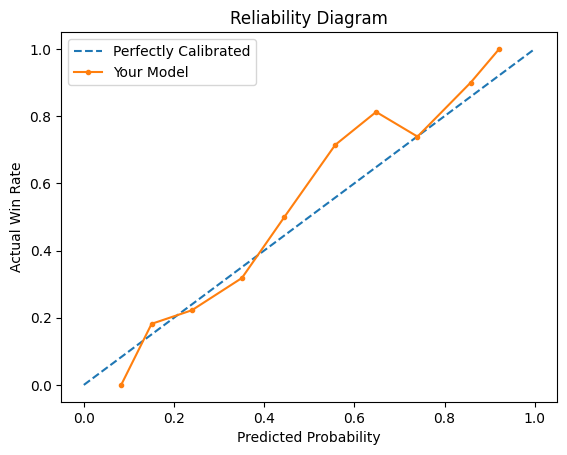

In [ ]:
from sklearn.calibration import calibration_curve

# 1. Get raw probabilities (don't use the threshold yet!)
model.eval()
with torch.no_grad():
    ...
    # probs = model(X_test).cpu().numpy()

# 2. Calculate calibration
# n_bins=10 means we check buckets: 0-10%, 10-20%, etc.
prob_true, prob_pred = calibration_curve(y_valid, vote_pred, n_bins=10)

# 3. Plot
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred, prob_true, marker='.', label='Your Model')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Win Rate')
plt.legend()
plt.title('Reliability Diagram')
plt.show()

## saving models

In [ ]:
import pickle
# Assume 'clf' is your trained DecisionTreeClassifier

# Save the model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(forest, f)

with open('ada_boost_model.pkl', 'wb') as f:
    pickle.dump(ada, f)

with open('XGBoost_model.pkl', 'wb') as f:
    pickle.dump(XGB, f)

In [ ]:
# Load the model later
with open('decision_tree_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Getting a Look

In [ ]:
# db_used
# db[["season","team1","team2"]]
X[:882]

(882, 13)

In [ ]:
c1, c2, c3, c4 =[0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]
xgb_probs = XGB.predict_proba(X[:882])[:,-1]
ada_probs = ada.predict_proba(X[:882])[:,-1]
rf_probs = forest.predict_proba(X[:882])[:,-1]
nn_probs = model(torch.as_tensor(X[:882], dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

In [ ]:
# y[:882]
# db.loc[((vote_pred >= 0.46697903412679714) == y[:882].reshape(-1)) & (((db["team2_seed"] > db["team1_seed"]) & (db["win"] == 0)) | ((db["team1_seed"] > db["team2_seed"]) & (db["win"] == 1)) ),].head(30)
db.loc[((vote_pred >= 0.46697903412679714) != y[:882].reshape(-1)),].head(20)

,season,round,team1,team2,team1_seed,team2_seed,win,SRS_team1,SOS_team1,FG%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
10,2025,32,BYU,Wisconsin,6,3,1,19.07,10.21,0.482234,...,3.314286,4.725845,9.685714,13.810875,18.457143,26.318068,0.481356,0.751469,0.499093,0.337530
17,2025,64,Clemson,McNeese State,5,12,0,17.81,7.51,0.464962,...,3.000000,4.484635,13.303030,19.886412,15.939394,23.827455,0.369279,0.712107,0.527341,0.351920
25,2025,32,Illinois,Kentucky,6,3,0,21.59,12.79,0.450071,...,2.878788,3.893762,9.787879,13.238790,17.909091,24.223297,0.417118,0.754634,0.512516,0.358583
31,2025,64,Louisville,Creighton,8,9,0,18.49,9.49,0.454410,...,3.147059,4.571355,7.470588,10.851629,15.823529,22.984946,0.490166,0.747581,0.500917,0.284679
36,2025,64,Marquette,New Mexico,7,10,0,18.19,10.37,0.445252,...,4.090909,5.450664,14.272727,19.016761,19.272727,25.678683,0.322952,0.775718,0.534081,0.371826
40,2025,32,Ole Miss,Iowa State,6,3,1,18.28,12.80,0.442259,...,3.424242,4.791816,14.606061,20.439426,18.303030,25.612891,0.368613,0.739417,0.522428,0.384776
49,2025,64,Missouri,Drake,6,11,0,19.49,9.49,0.485294,...,2.333333,3.809406,13.060606,21.322779,17.181818,28.051081,0.371911,0.777778,0.568269,0.425558
51,2025,64,Kansas,Arkansas,7,10,0,20.09,13.56,0.471253,...,2.606061,3.625804,11.787879,16.400441,17.303030,24.073654,0.367326,0.735455,0.492602,0.355359
56,2025,32,Arkansas,St. John's (NY),10,2,1,17.09,11.70,0.466181,...,3.794118,5.210858,14.558824,19.995153,17.264706,23.711423,0.303098,0.737500,0.546308,0.301751
60,2025,4,Auburn,Florida,1,1,0,28.68,15.13,0.482521,...,3.117647,4.330309,11.441176,15.891415,17.088235,23.734993,0.435921,0.736885,0.553119,0.325678


# Using Model

In [ ]:
import torch
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

class Model(torch.nn.Module):
    def __init__(self, input_size: int, output_size: int = 1, hidden_dim: int = 32, n_layers: int = 2, dropout: float= .5):
        super(Model, self).__init__()

        self.layers = torch.nn.ModuleList()
        self.bn_layers = torch.nn.ModuleList() # New list for BatchNorm

        # Input Layer
        # Pro-tip: bias=False because BN has its own 'beta' parameter that handles shifting
        self.layers.append(torch.nn.Linear(input_size, hidden_dim, bias=False))
        self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        # Hidden Layers
        for _ in range(n_layers):
            self.layers.append(torch.nn.Linear(hidden_dim, hidden_dim, bias=False))
            self.bn_layers.append(torch.nn.BatchNorm1d(hidden_dim))

        self.dropout = torch.nn.Dropout(dropout)
        self.output_layer = torch.nn.Linear(hidden_dim, output_size)
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        # Use zip to iterate through both the linear and BN layers together
        for layer, bn in zip(self.layers, self.bn_layers):
            x = layer(x)
            x = bn(x)        # Normalize before activation
            x = self.relu(x)
            x = self.dropout(x)

        x = self.output_layer(x)
        return self.sigmoid(x)

In [ ]:
NN = Model(13, n_layers = 2, hidden_dim=32, dropout = .3)

NN.load_state_dict(torch.load("mod13.pth"))

NN.eval()

Model(
  (layers): ModuleList(
    (0): Linear(in_features=13, out_features=32, bias=False)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=False)
  )
  (bn_layers): ModuleList(
    (0-2): 3 x BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [ ]:
with open('random_forest_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('ada_boost_model.pkl', 'rb') as f:
    ad = pickle.load(f)

with open('XGBoost_model.pkl', 'rb') as f:
    xg = pickle.load(f)

## using it on 2025 for practice

In [ ]:
db25 = pd.read_csv("database25.csv")
db25 = db25.loc[db25["round"] == 64,].reset_index().copy()
db25["matchup_id"] = range(32)

In [ ]:
seeds = {(list(db25["team1"]) + list(db25["team2"]))[i] : (list(db25["team1_seed"]) + list(db25["team2_seed"]))[i] for i in range(64)}

In [ ]:
scaler = StandardScaler()
db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_eFG"] = db25["eFG_team1"] - db25["opp_eFG_team2"]
db_used["net_TOV_pct"] = db25["TOV_pct_team1"] - db25["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db25["eFG_team2"] - db25["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db25["TOV_pct_team2"] - db25["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)

In [ ]:
# db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","srs","sos","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)]
# db_used

In [ ]:
c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

xgb_probs = xg.predict_proba(X)[:,-1]
ada_probs = ad.predict_proba(X)[:,-1]
rf_probs = rf.predict_proba(X)[:,-1]
nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

In [ ]:
db_eval = pd.DataFrame(np.vstack([db25.loc[:,["matchup_id","team1","team2","team1_seed","team2_seed"]],
           db25.loc[:,["matchup_id","team2","team1","team2_seed","team1_seed"]]]), columns = [
               "matchup_id","team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
# db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
# db_pred["pred_win"] = 0
# db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

db_eval1 = db_eval[:32].reset_index().copy()
db_eval2 = db_eval[-32:].reset_index().copy()
db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:32].copy()
db_eval["winner"] = ""
for i in range(len(db_eval)):
    t = np.random.random()
    if t <= db_eval.loc[i, "avg_pred"]:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
    else:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
db_eval.head()

,matchup_id,team1,team2,team1_seed,team2_seed,team1_pred,avg_pred,winner
0,0,Duke,Mount St. Mary's,1,16,0.949436,0.931067,Duke
1,1,Mississippi State,Baylor,8,9,0.373730,0.433577,Mississippi State
2,2,Oregon,Liberty,5,12,0.664668,0.627335,Oregon
3,3,Arizona,Akron,4,13,0.803664,0.813029,Akron
4,4,BYU,VCU,6,11,0.660837,0.683302,BYU


In [ ]:
needed_cols: list[str] = ["team",'SRS','SOS','off_rtg', 'def_rtg', 'pace',
                          'eFG', "opp_eFG",
                          'ORB_pct', 'FT_FGA','TOV_pct', "opp_TOV_pct",'3PAr']

In [ ]:
teams25 = pd.read_csv("25teamstats.csv")
# teams25.head()

In [ ]:
team1: list[str] = list()
team2: list[str] = list()
for i in range(0,len(db_eval),2):
    t1, t2 = list(db_eval["winner"])[i:(i +2)]
    team1.append(t1)
    team2.append(t2)

db_next = pd.DataFrame(columns = ["team1","team2"])
db_next["team1"] = team1
db_next["team2"] = team2

db_next = pd.merge(
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
db_next["team1_seed"] = 0
db_next["team2_seed"] = 0
for i in range(len(db_next)):
    db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
    db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

scaler = StandardScaler()
# db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
db_used = db_next.copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

# adding net stats
db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)

In [ ]:
c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

xgb_probs = xg.predict_proba(X)[:,-1]
ada_probs = ad.predict_proba(X)[:,-1]
rf_probs = rf.predict_proba(X)[:,-1]
nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
# db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
# db_pred["pred_win"] = 0
# db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

db_eval1 = db_eval[:16].reset_index().copy()
db_eval2 = db_eval[-16:].reset_index().copy()
db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:16].copy()
db_eval["winner"] = ""
for i in range(len(db_eval)):
    t = np.random.random()
    if t <= db_eval.loc[i, "avg_pred"]:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
    else:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
db_eval

,team1,team2,team1_seed,team2_seed,team1_pred,avg_pred,winner
0,Duke,Mississippi State,1,8,0.866538,0.859648,Duke
1,Oregon,Akron,5,13,0.820653,0.805322,Akron
2,BYU,Wisconsin,6,3,0.632648,0.588772,BYU
3,Saint Mary's,Robert Morris,7,15,0.858981,0.876755,Saint Mary's
4,Houston,Gonzaga,1,8,0.679503,0.693797,Houston
5,Clemson,Purdue,5,4,0.366516,0.357933,Purdue
6,Xavier,Kentucky,11,3,0.288639,0.281257,Kentucky
7,Utah State,Tennessee,10,2,0.180982,0.226461,Tennessee
8,Auburn,Louisville,1,8,0.805531,0.800075,Louisville
9,UC-San Diego,Texas A&M,12,4,0.327965,0.349696,UC-San Diego


In [ ]:
team1: list[str] = list()
team2: list[str] = list()
for i in range(0,len(db_eval),2):
    t1, t2 = list(db_eval["winner"])[i:(i +2)]
    team1.append(t1)
    team2.append(t2)

db_next = pd.DataFrame(columns = ["team1","team2"])
db_next["team1"] = team1
db_next["team2"] = team2

db_next = pd.merge(
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
db_next["team1_seed"] = 0
db_next["team2_seed"] = 0
for i in range(len(db_next)):
    db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
    db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

scaler = StandardScaler()
# db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
db_used = db_next.copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

# adding net stats
db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)

In [ ]:
c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

xgb_probs = xg.predict_proba(X)[:,-1]
ada_probs = ad.predict_proba(X)[:,-1]
rf_probs = rf.predict_proba(X)[:,-1]
nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
# db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
# db_pred["pred_win"] = 0
# db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

db_eval1 = db_eval[:8].reset_index().copy()
db_eval2 = db_eval[-8:].reset_index().copy()
db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:8].copy()
db_eval["winner"] = ""
for i in range(len(db_eval)):
    t = np.random.random()
    if t <= db_eval.loc[i, "avg_pred"]:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
    else:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
db_eval

,team1,team2,team1_seed,team2_seed,team1_pred,avg_pred,winner
0,Duke,Akron,1,13,0.920894,0.892707,Duke
1,BYU,Saint Mary's,6,7,0.575523,0.594822,BYU
2,Houston,Purdue,1,4,0.598900,0.663757,Houston
3,Kentucky,Tennessee,3,2,0.304554,0.362343,Kentucky
4,Louisville,UC-San Diego,8,12,0.676262,0.681845,UC-San Diego
5,Lipscomb,Marquette,14,7,0.106964,0.124014,Marquette
6,Florida,Maryland,1,4,0.743361,0.750430,Florida
7,Texas Tech,St. John's (NY),3,2,0.666906,0.660437,St. John's (NY)


In [ ]:
team1: list[str] = list()
team2: list[str] = list()
for i in range(0,len(db_eval),2):
    t1, t2 = list(db_eval["winner"])[i:(i +2)]
    team1.append(t1)
    team2.append(t2)

db_next = pd.DataFrame(columns = ["team1","team2"])
db_next["team1"] = team1
db_next["team2"] = team2

db_next = pd.merge(
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
db_next["team1_seed"] = 0
db_next["team2_seed"] = 0
for i in range(len(db_next)):
    db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
    db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

scaler = StandardScaler()
# db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
db_used = db_next.copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

# adding net stats
db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)

c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

xgb_probs = xg.predict_proba(X)[:,-1]
ada_probs = ad.predict_proba(X)[:,-1]
rf_probs = rf.predict_proba(X)[:,-1]
nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
# db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
# db_pred["pred_win"] = 0
# db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

db_eval1 = db_eval[:4].reset_index().copy()
db_eval2 = db_eval[-4:].reset_index().copy()
db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:4].copy()
db_eval["winner"] = ""
for i in range(len(db_eval)):
    t = np.random.random()
    if t <= db_eval.loc[i, "avg_pred"]:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
    else:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
db_eval

,team1,team2,team1_seed,team2_seed,team1_pred,avg_pred,winner
0,Duke,BYU,1,6,0.809399,0.828389,BYU
1,Houston,Kentucky,1,3,0.679336,0.724253,Houston
2,UC-San Diego,Marquette,12,7,0.241705,0.278669,Marquette
3,Florida,St. John's (NY),1,2,0.800205,0.780758,St. John's (NY)


In [ ]:
team1: list[str] = list()
team2: list[str] = list()
for i in range(0,len(db_eval),2):
    t1, t2 = list(db_eval["winner"])[i:(i +2)]
    team1.append(t1)
    team2.append(t2)

db_next = pd.DataFrame(columns = ["team1","team2"])
db_next["team1"] = team1
db_next["team2"] = team2

db_next = pd.merge(
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
db_next["team1_seed"] = 0
db_next["team2_seed"] = 0
for i in range(len(db_next)):
    db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
    db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

scaler = StandardScaler()
# db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
db_used = db_next.copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

# adding net stats
db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)

c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

xgb_probs = xg.predict_proba(X)[:,-1]
ada_probs = ad.predict_proba(X)[:,-1]
rf_probs = rf.predict_proba(X)[:,-1]
nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
# db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
# db_pred["pred_win"] = 0
# db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

db_eval1 = db_eval[:2].reset_index().copy()
db_eval2 = db_eval[-2:].reset_index().copy()
db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:2].copy()
db_eval["winner"] = ""
for i in range(len(db_eval)):
    t = np.random.random()
    if t <= db_eval.loc[i, "avg_pred"]:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
    else:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
db_eval

,team1,team2,team1_seed,team2_seed,team1_pred,avg_pred,winner
0,BYU,Houston,6,1,0.116852,0.125869,Houston
1,Marquette,St. John's (NY),7,2,0.524022,0.537253,Marquette


In [ ]:
team1: list[str] = list()
team2: list[str] = list()
for i in range(0,len(db_eval),2):
    t1, t2 = list(db_eval["winner"])[i:(i +2)]
    team1.append(t1)
    team2.append(t2)

db_next = pd.DataFrame(columns = ["team1","team2"])
db_next["team1"] = team1
db_next["team2"] = team2

db_next = pd.merge(
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
    pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
db_next["team1_seed"] = 0
db_next["team2_seed"] = 0
for i in range(len(db_next)):
    db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
    db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

scaler = StandardScaler()
# db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
db_used = db_next.copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

# adding net stats
db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)

c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

xgb_probs = xg.predict_proba(X)[:,-1]
ada_probs = ad.predict_proba(X)[:,-1]
rf_probs = rf.predict_proba(X)[:,-1]
nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                 c3 * rf_probs + c1 * nn_probs)

db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
           db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
               "team1","team2","team1_seed","team2_seed"
           ])
db_eval["team1_pred"] = vote_pred
# db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
# db_pred["pred_win"] = 0
# db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

db_eval1 = db_eval[:1].reset_index().copy()
db_eval2 = db_eval[-1:].reset_index().copy()
db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
db_eval = db_eval[:1].copy()
db_eval["winner"] = ""
for i in range(len(db_eval)):
    t = np.random.random()
    if t <= db_eval.loc[i, "avg_pred"]:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
    else:
        db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
db_eval

,team1,team2,team1_seed,team2_seed,team1_pred,avg_pred,winner
0,Houston,Marquette,1,7,0.818832,0.839044,Houston


In [ ]:
scaler = StandardScaler()
db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
for comp in comps:
    db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

# adding net stats
db_used["net_eFG"] = db25["eFG_team1"] - db25["opp_eFG_team2"]
db_used["net_TOV_pct"] = db25["TOV_pct_team1"] - db25["opp_TOV_pct_team2"]

mirrored = -db_used.iloc[:,:-2].copy()
mirrored["net_eFG"] = db25["eFG_team2"] - db25["opp_eFG_team1"]
mirrored["net_TOV_pct"] = db25["TOV_pct_team2"] - db25["opp_TOV_pct_team1"]

X = np.vstack([np.array(db_used), np.array(mirrored)])

# X = np.array(db_used)
X = scaler.fit_transform(X)
db_next = db25.copy()

rounds: list[int] = list(2**i for i in range(6,0,-1))
# pd.DataFrame([64]*32, columns = ["round"])
results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
  'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
for round in rounds:

    c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

    xgb_probs = xg.predict_proba(X)[:,-1]
    ada_probs = ad.predict_proba(X)[:,-1]
    rf_probs = rf.predict_proba(X)[:,-1]
    nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

    vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                    c3 * rf_probs + c1 * nn_probs)

    db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
              db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                  "team1","team2","team1_seed","team2_seed"
              ])
    db_eval["team1_pred"] = vote_pred
    # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
    # db_pred["pred_win"] = 0
    # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

    db_eval1 = db_eval[:(round//2)].reset_index().copy()
    db_eval2 = db_eval[-(round//2):].reset_index().copy()
    db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
    db_eval = db_eval[:(round//2)].copy()
    db_eval["winner"] = ""
    for i in range(len(db_eval)):
        t = np.random.random()
        if t <= db_eval.loc[i, "avg_pred"]:
            db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
        else:
            db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
    if len(results) > 1:
        results = pd.concat([results,
            pd.concat([
            pd.DataFrame([round]*(round//2), columns = ["round"]),
            db_eval
            ], axis = 1)], axis = 0)
    else:
        results = pd.concat([
            pd.DataFrame([round]*(round//2), columns = ["round"]),
            db_eval
            ], axis = 1)
    if round != 2:
        team1: list[str] = list()
        team2: list[str] = list()
        for i in range(0,len(db_eval),2):
            t1, t2 = list(db_eval["winner"])[i:(i +2)]
            team1.append(t1)
            team2.append(t2)

        db_next = pd.DataFrame(columns = ["team1","team2"])
        db_next["team1"] = team1
        db_next["team2"] = team2

        db_next = pd.merge(
            pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
            pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
        db_next["team1_seed"] = 0
        db_next["team2_seed"] = 0
        for i in range(len(db_next)):
            db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
            db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
        db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

        scaler = StandardScaler()
        # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
        db_used = db_next.copy()
        comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
        db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
        for comp in comps:
            db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
        db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

        # adding net stats
        db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
        db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

        mirrored = -db_used.iloc[:,:-2].copy()
        mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
        mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

        X = np.vstack([np.array(db_used), np.array(mirrored)])

In [ ]:
def MC_MM(finishes: "pd.DataFrame", bracket) -> "pd.DataFrame":

    scaler = StandardScaler()
    db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
    comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
    db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
    for comp in comps:
        db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
    db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

    # adding net stats
    db_used["net_eFG"] = db25["eFG_team1"] - db25["opp_eFG_team2"]
    db_used["net_TOV_pct"] = db25["TOV_pct_team1"] - db25["opp_TOV_pct_team2"]

    mirrored = -db_used.iloc[:,:-2].copy()
    mirrored["net_eFG"] = db25["eFG_team2"] - db25["opp_eFG_team1"]
    mirrored["net_TOV_pct"] = db25["TOV_pct_team2"] - db25["opp_TOV_pct_team1"]

    X = np.vstack([np.array(db_used), np.array(mirrored)])

    # X = np.array(db_used)
    X = scaler.fit_transform(X)
    db_next = db25.copy()

    rounds: list[int] = list(2**i for i in range(6,0,-1))
    # pd.DataFrame([64]*32, columns = ["round"])
    results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
      'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
    for round in rounds:

        c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

        xgb_probs = xg.predict_proba(X)[:,-1]
        ada_probs = ad.predict_proba(X)[:,-1]
        rf_probs = rf.predict_proba(X)[:,-1]
        nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

        vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                        c3 * rf_probs + c1 * nn_probs)

        db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
                  db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                      "team1","team2","team1_seed","team2_seed"
                  ])
        db_eval["team1_pred"] = vote_pred
        # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
        # db_pred["pred_win"] = 0
        # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

        db_eval1 = db_eval[:(round//2)].reset_index().copy()
        db_eval2 = db_eval[-(round//2):].reset_index().copy()
        db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
        db_eval = db_eval[:(round//2)].copy()
        db_eval["winner"] = ""
        for i in range(len(db_eval)):
            t = np.random.random()
            if t <= db_eval.loc[i, "avg_pred"]:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
            else:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
        if len(results) > 1:
            results = pd.concat([results,
                pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)], axis = 0)
        else:
            results = pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)
        if round != 2:
            team1: list[str] = list()
            team2: list[str] = list()
            for i in range(0,len(db_eval),2):
                t1, t2 = list(db_eval["winner"])[i:(i +2)]
                team1.append(t1)
                team2.append(t2)

            db_next = pd.DataFrame(columns = ["team1","team2"])
            db_next["team1"] = team1
            db_next["team2"] = team2

            db_next = pd.merge(
                pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
                pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
            db_next["team1_seed"] = 0
            db_next["team2_seed"] = 0
            for i in range(len(db_next)):
                db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
                db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
            db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

            scaler = StandardScaler()
            # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
            db_used = db_next.copy()
            comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            for comp in comps:
                db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

            # adding net stats
            db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
            db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

            mirrored = -db_used.iloc[:,:-2].copy()
            mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
            mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

            X = np.vstack([np.array(db_used), np.array(mirrored)])

    for team in teams25["team"]:
        finish = results.loc[(results["team1"] == team) |
        (results["team2"] == team),"round"].min()
        # finishes[team] = finish
        if finish == 2:
            if team == results.loc[results["round"] == 2,"winner"].values[0]:
                finish = 1
        finishes.loc[finishes["team"] == team,str(finish)] += 1


    return finishes

In [ ]:
finishes = {teams25["team"].values[i]:0 for i in range(64)}
for team in finishes.keys():
    finish = results.loc[(results["team1"] == team) |
     (results["team2"] == team),"round"].min()
    finishes[team] = finish
    if finish == 2:
        if team == results.loc[results["round"] == 2,"winner"].values[0]:
            finishes[team] = 1

NameError: name 'results' is not defined

In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teams25["team"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64

for team in teams25["team"]:
    finish = results.loc[(results["team1"] == team) |
     (results["team2"] == team),"round"].min()
    # finishes[team] = finish
    if finish == 2:
        if team == results.loc[results["round"] == 2,"winner"].values[0]:
            finish = 1
    finishes.loc[finishes["team"] == team,str(finish)] += 1


finishes

,team,64,32,16,8,4,2,1
0,Duke,0,1,0,0,0,0,0
1,Mount St. Mary's,1,0,0,0,0,0,0
2,Mississippi State,1,0,0,0,0,0,0
3,Baylor,0,0,1,0,0,0,0
4,Oregon,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
59,UNC Wilmington,1,0,0,0,0,0,0
60,Kansas,1,0,0,0,0,0,0
61,Arkansas,0,0,1,0,0,0,0
62,St. John's (NY),0,1,0,0,0,0,0


In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teams25["team"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)

for _ in range(5000):
    finishes = MC_MM(finishes)
    if (_ + 1) % 100 == 0:
        print(_ + 1)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000


In [ ]:
from google.colab import files
finishes.to_csv("finishes.csv")
files.download("finishes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
finishes = pd.read_csv("finishes-2.csv")

In [ ]:
sum(finishes[str(i)][0] for i in [2**i for i in range(6)])

np.int64(4659)

# MC storing bracket

In [ ]:
class Bracket:

    def __init__(self, round_64: list[tuple[str,str]]):

        self.rounds: dict[int, list[tuple[str, str]]] = dict()
        self.rounds[64] = round_64
        for round in list(2**i for i in range(5,0,-1)):
            self.rounds[round] = list()

In [ ]:
def MC_MM(finishes: "pd.DataFrame", bracket) -> "pd.DataFrame":

    scaler = StandardScaler()
    db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
    comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
    db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
    for comp in comps:
        db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
    db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c)].copy()

    # adding net stats
    db_used["net_eFG"] = db25["eFG_team1"] - db25["opp_eFG_team2"]
    db_used["net_TOV_pct"] = db25["TOV_pct_team1"] - db25["opp_TOV_pct_team2"]

    mirrored = -db_used.iloc[:,:-2].copy()
    mirrored["net_eFG"] = db25["eFG_team2"] - db25["opp_eFG_team1"]
    mirrored["net_TOV_pct"] = db25["TOV_pct_team2"] - db25["opp_TOV_pct_team1"]

    X = np.vstack([np.array(db_used), np.array(mirrored)])

    # X = np.array(db_used)
    X = scaler.fit_transform(X)
    db_next = db25.copy()

    rounds: list[int] = list(2**i for i in range(6,0,-1))
    # pd.DataFrame([64]*32, columns = ["round"])
    results: "pd.DataFrame" = pd.DataFrame(columns = ["round",'team1', 'team2',
      'team1_seed', 'team2_seed', 'team1_pred', 'avg_pred','winner'])
    for round in rounds:

        c1, c2, c3, c4 = [0.44440669 ,0.16464701 ,0.32866461 ,0.06228169]

        xgb_probs = xg.predict_proba(X)[:,-1]
        ada_probs = ad.predict_proba(X)[:,-1]
        rf_probs = rf.predict_proba(X)[:,-1]
        nn_probs = NN(torch.tensor(X, dtype = torch.float32)).reshape(-1).detach().numpy()

        vote_pred = (c4 * xgb_probs + c2 * ada_probs +
                        c3 * rf_probs + c1 * nn_probs)

        db_eval = pd.DataFrame(np.vstack([db_next.loc[:,["team1","team2","team1_seed","team2_seed"]],
                  db_next.loc[:,["team2","team1","team2_seed","team1_seed"]]]), columns = [
                      "team1","team2","team1_seed","team2_seed"
                  ])
        db_eval["team1_pred"] = vote_pred
        # db_eval.loc[(db_eval["team1_seed"] == 10) | (db_eval["team2_seed"] == 10),]
        # db_pred["pred_win"] = 0
        # db_eval.loc[(vote_pred >= 0.46697903412679714),"pred_win"] = 1

        db_eval1 = db_eval[:(round//2)].reset_index().copy()
        db_eval2 = db_eval[-(round//2):].reset_index().copy()
        db_eval["avg_pred"] = (db_eval1["team1_pred"] + (1 - db_eval2["team1_pred"]))/2
        db_eval = db_eval[:(round//2)].copy()
        db_eval["winner"] = ""
        for i in range(len(db_eval)):
            t = np.random.random()
            if t <= db_eval.loc[i, "avg_pred"]:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team1"]
            else:
                db_eval.loc[i, "winner"] = db_eval.loc[i, "team2"]
            # list(zip(db25["team1"], db25["team2"]))
        # bracket.rounds[round//2] = list((db_eval["winner"].values[::2][i],
        #                                 db_eval["winner"].values[1::2][i]) for i in range(round//4))
        bracket.rounds[round//2] = list(db_eval["winner"].values)
        if len(results) > 1:
            results = pd.concat([results,
                pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)], axis = 0)
        else:
            results = pd.concat([
                pd.DataFrame([round]*(round//2), columns = ["round"]),
                db_eval
                ], axis = 1)
        if round != 2:
            team1: list[str] = list()
            team2: list[str] = list()
            for i in range(0,len(db_eval),2):
                t1, t2 = list(db_eval["winner"])[i:(i +2)]
                team1.append(t1)
                team2.append(t2)
                # bracket.rounds[round].append((t1,t2))

            db_next = pd.DataFrame(columns = ["team1","team2"])
            db_next["team1"] = team1
            db_next["team2"] = team2

            db_next = pd.merge(
                pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team1"), left_on = "team1", right_on = "team_team1"),
                pd.merge(db_next, teams25.loc[:,needed_cols].add_suffix("_team2"), left_on = "team2", right_on = "team_team2"))
            db_next["team1_seed"] = 0
            db_next["team2_seed"] = 0
            for i in range(len(db_next)):
                db_next.loc[i, "team1_seed"] = seeds[db_next.loc[i, "team1"]]
                db_next.loc[i, "team2_seed"] = seeds[db_next.loc[i, "team2"]]
            db_next = db_next.drop(["team_team1", "team_team2"], axis = 1)

            scaler = StandardScaler()
            # db_used = db25.loc[:,list(c for c in db25.columns if any(t in c for t in {"seed","SRS","SOS","off_rtg","def_rtg","pace","eFG","ORB_pct","TOV_pct","FT_FGA", "3PAr"}) and "opp" not in c)].copy()
            db_used = db_next.copy()
            comps = list(c.split('_team1')[0] for c in db_used.columns if "_team1" in c)
            db_used["seed_diff"] = db_used["team1_seed"] - db_used["team2_seed"]
            for comp in comps:
                db_used[f"{comp}_diff"] = db_used[f"{comp}_team1"] - db_used[f"{comp}_team2"]
            db_used = db_used.loc[:,list(c for c in db_used.columns if "diff" in c and "opp" not in c)].copy()

            # adding net stats
            db_used["net_eFG"] = db_next["eFG_team1"] - db_next["opp_eFG_team2"]
            db_used["net_TOV_pct"] = db_next["TOV_pct_team1"] - db_next["opp_TOV_pct_team2"]

            mirrored = -db_used.iloc[:,:-2].copy()
            mirrored["net_eFG"] = db_next["eFG_team2"] - db_next["opp_eFG_team1"]
            mirrored["net_TOV_pct"] = db_next["TOV_pct_team2"] - db_next["opp_TOV_pct_team1"]

            X = np.vstack([np.array(db_used), np.array(mirrored)])

    for team in teams25["team"]:
        finish = results.loc[(results["team1"] == team) |
        (results["team2"] == team),"round"].min()
        # finishes[team] = finish
        if finish == 2:
            # bracket.rounds[2].append(team)
            if team == results.loc[results["round"] == 2,"winner"].values[0]:
                finish = 1
                bracket.rounds[1] = team
            # else:
            #     bracket.rounds[2].append(team)
        finishes.loc[finishes["team"] == team,str(finish)] += 1


    return finishes, bracket

In [ ]:
finishes = pd.DataFrame(columns = ["team"] + [str(2**i) for i in range(6,-1,-1)])
finishes["team"] = teams25["team"]
for col in finishes.columns[1:]:
    finishes[col] = [0]*64
finishes["seed"] = list(seeds[team] for team in finishes["team"].values)

In [ ]:
brackets = list(Bracket(round_64 = [(db25["team1"][i], db25["team2"][i]) for i in range(32)]) for _ in range(10000))
for brack in brackets:
    finishes, brack = MC_MM(finishes, brack)

In [ ]:
brackets[0].rounds

{64: [('Duke', "Mount St. Mary's"),
  ('Mississippi State', 'Baylor'),
  ('Oregon', 'Liberty'),
  ('Arizona', 'Akron'),
  ('BYU', 'VCU'),
  ('Wisconsin', 'Montana'),
  ("Saint Mary's", 'Vanderbilt'),
  ('Alabama', 'Robert Morris'),
  ('Houston', 'SIU-Edwardsville'),
  ('Gonzaga', 'Georgia'),
  ('Clemson', 'McNeese State'),
  ('Purdue', 'High Point'),
  ('Illinois', 'Xavier'),
  ('Kentucky', 'Troy'),
  ('UCLA', 'Utah State'),
  ('Tennessee', 'Wofford'),
  ('Auburn', 'Alabama State'),
  ('Louisville', 'Creighton'),
  ('Michigan', 'UC-San Diego'),
  ('Texas A&M', 'Yale'),
  ('Ole Miss', 'UNC'),
  ('Iowa State', 'Lipscomb'),
  ('Marquette', 'New Mexico'),
  ('Michigan State', 'Bryant'),
  ('Florida', 'Norfolk State'),
  ('UConn', 'Oklahoma'),
  ('Memphis', 'Colorado State'),
  ('Maryland', 'Grand Canyon'),
  ('Missouri', 'Drake'),
  ('Texas Tech', 'UNC Wilmington'),
  ('Kansas', 'Arkansas'),
  ("St. John's (NY)", 'Omaha')],
 32: ["Mount St. Mary's",
  'Mississippi State',
  'Oregon',
  'Ar

In [ ]:
from collections import Counter

def bracket_signature(bracket):

    sig = []

    rounds = {round:brackets[0].rounds[round] for round in [16,8,4,2,1]}

    for r in sorted(rounds.keys(), reverse=True):
        games = bracket.rounds[r]

        if isinstance(games, list):
            sig.append(tuple(games))
        else:  # championship winner
            sig.append(games)

    return tuple(sig)

counter = Counter()

for bracket in brackets:
    sig = bracket_signature(bracket)
    counter[sig] += 1

In [ ]:
{sig:counter[sig] for sig in counter.keys() if counter[sig] >= 4}

{(('Duke',
   'Arizona',
   'Wisconsin',
   'Alabama',
   'Houston',
   'Purdue',
   'Kentucky',
   'Tennessee',
   'Auburn',
   'Texas A&M',
   'Iowa State',
   'Michigan State',
   'Florida',
   'Maryland',
   'Texas Tech',
   "St. John's (NY)"),
  ('Duke',
   'Alabama',
   'Houston',
   'Tennessee',
   'Auburn',
   'Michigan State',
   'Florida',
   'Texas Tech'),
  ('Duke', 'Houston', 'Auburn', 'Florida'),
  ('Duke', 'Auburn'),
  'Duke'): 5}

In [ ]:
# finishes.sort_values("1", ascending = 0).head()
# finishes.loc[(finishes["seed"] == 6) | (finishes["seed"] == 11),]
finishes.loc[(finishes["1"] >= 1),].sort_values("seed", ascending = 0).head()

,team,64,32,16,8,4,2,1,seed
61,Arkansas,6369,2434,813,345,35,3,1,10
45,New Mexico,5581,3296,936,165,19,2,1,10
3,Baylor,4265,4910,501,222,83,16,3,9
18,Gonzaga,3255,5433,290,595,347,64,16,8
50,UConn,2795,6318,639,221,25,1,1,8


In [ ]:
finishes_analysis = finishes.copy()

In [ ]:
finishes.to_csv("finishes50k.csv")

In [ ]:
finishes_analysis["32_prob"] = 1 - finishes_analysis["64"]/10000
finishes_analysis["16_prob"] = 1 - (finishes_analysis["64"] + finishes_analysis["32"])/10000
finishes_analysis["8_prob"] = 1 - (finishes_analysis["64"] + finishes_analysis["32"] + finishes_analysis["16"])/10000
finishes_analysis["4_prob"] = 1 - (finishes_analysis["64"] + finishes_analysis["32"] + finishes_analysis["16"] + finishes_analysis["8"])/10000
finishes_analysis["2_prob"] = 1 - (finishes_analysis["64"] + finishes_analysis["32"] + finishes_analysis["16"] + finishes_analysis["8"] + finishes_analysis["4"])/10000
finishes_analysis["1_prob"] = finishes["1"]/10000

In [ ]:
finishes_analysis.loc[finishes_analysis["seed"] >= 9,["team","seed","32_prob"]]

,team,seed,32_prob
1,Mount St. Mary's,16,0.0664
3,Baylor,9,0.5735
5,Liberty,12,0.3819
7,Akron,13,0.1841
9,VCU,11,0.3150
11,Montana,14,0.1653
13,Vanderbilt,10,0.3940
15,Robert Morris,15,0.1269
17,SIU-Edwardsville,16,0.0838
19,Georgia,9,0.3255


## we are not cooking

In [ ]:
data = {finishes["team"][i] : 5000 - finishes["64"][i] for i in range(64)}
dict(sorted(data.items(), key=lambda item: item[1], reverse=True))

{'Auburn': np.int64(4692),
 'Duke': np.int64(4659),
 'Florida': np.int64(4578),
 'Houston': np.int64(4567),
 'Alabama': np.int64(4385),
 'Tennessee': np.int64(4267),
 'Michigan State': np.int64(4252),
 'Maryland': np.int64(4227),
 'Wisconsin': np.int64(4123),
 'Arizona': np.int64(4121),
 'Texas Tech': np.int64(4109),
 "St. John's (NY)": np.int64(4095),
 'Iowa State': np.int64(4084),
 'Kentucky': np.int64(3871),
 'Purdue': np.int64(3840),
 'Texas A&M': np.int64(3718),
 'UConn': np.int64(3567),
 'BYU': np.int64(3470),
 'Gonzaga': np.int64(3431),
 'Illinois': np.int64(3430),
 'Clemson': np.int64(3268),
 'UCLA': np.int64(3244),
 'Colorado State': np.int64(3243),
 'Kansas': np.int64(3179),
 'Oregon': np.int64(3118),
 "Saint Mary's": np.int64(3075),
 'Michigan': np.int64(2966),
 'Baylor': np.int64(2875),
 'Missouri': np.int64(2810),
 'Marquette': np.int64(2775),
 'Ole Miss': np.int64(2762),
 'Louisville': np.int64(2643),
 'Creighton': np.int64(2357),
 'UNC': np.int64(2238),
 'New Mexico': np

In [ ]:
# finishes.sort_values("64", ascending = 1).head(32)
upsets: int = 0
finishes[["team","64","seed"]]
for i in range(32):
    temp = finishes[["team","64","seed"]][int(2*i):int(2*(i + 1))].reset_index()
    print(f"#{temp["seed"][0]} {temp["team"][0]} vs #{temp["seed"][1]} {temp["team"][1]}")
    winner = np.random.choice(temp["team"], p = (5000 - temp["64"])/5000)
    if temp.loc[temp["team"] == winner, "seed"].values >= 9:
        upsets += 1
        print("UPSET!")
    print(f"Winner: {winner}")
    print()
print(f"Number of upsets: {upsets}")

#1 Duke vs #16 Mount St. Mary's
Winner: Duke

#8 Mississippi State vs #9 Baylor
UPSET!
Winner: Baylor

#5 Oregon vs #12 Liberty
Winner: Oregon

#4 Arizona vs #13 Akron
Winner: Arizona

#6 BYU vs #11 VCU
Winner: BYU

#3 Wisconsin vs #14 Montana
Winner: Wisconsin

#7 Saint Mary's vs #10 Vanderbilt
UPSET!
Winner: Vanderbilt

#2 Alabama vs #15 Robert Morris
Winner: Alabama

#1 Houston vs #16 SIU-Edwardsville
Winner: Houston

#8 Gonzaga vs #9 Georgia
Winner: Gonzaga

#5 Clemson vs #12 McNeese State
Winner: Clemson

#4 Purdue vs #13 High Point
Winner: Purdue

#6 Illinois vs #11 Xavier
Winner: Illinois

#3 Kentucky vs #14 Troy
UPSET!
Winner: Troy

#7 UCLA vs #10 Utah State
Winner: UCLA

#2 Tennessee vs #15 Wofford
Winner: Tennessee

#1 Auburn vs #16 Alabama State
Winner: Auburn

#8 Louisville vs #9 Creighton
UPSET!
Winner: Creighton

#5 Michigan vs #12 UC-San Diego
Winner: Michigan

#4 Texas A&M vs #13 Yale
Winner: Texas A&M

#6 Ole Miss vs #11 UNC
Winner: Ole Miss

#3 Iowa State vs #14 Lipsc

# Visualizing neural net

In [ ]:
NN = Model(13, n_layers = 2, hidden_dim=32, dropout = .3)

NN.load_state_dict(torch.load("mod13v2.pth"))

NN.eval()

Model(
  (layers): ModuleList(
    (0): Linear(in_features=13, out_features=32, bias=False)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=False)
  )
  (bn_layers): ModuleList(
    (0-2): 3 x BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [ ]:
NN

Model(
  (layers): ModuleList(
    (0): Linear(in_features=13, out_features=32, bias=False)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=False)
  )
  (bn_layers): ModuleList(
    (0-2): 3 x BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [ ]:
!pip install torchviz

In [ ]:
# Source - https://stackoverflow.com/a/62458882
# Posted by stackoverflowuser2010, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-06, License - CC BY-SA 4.0

from torchviz import make_dot


batchX = next(iter(train_dataloader))[0]
yhat = NN(batchX)
make_dot(yhat, params=dict(list(NN.named_parameters()))).render("rnn_torchviz", format="png")

'rnn_torchviz.png'